In [1]:
import numpy as np
from scipy.signal import find_peaks
import sys
import os
sys.path.append('/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/utils/')
sys.path.append('/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/bond_based/')

from plot_utils import plot_cluster_size_distribution, analyze_bond_network, plot_rdfs, plot_3d_cluster_with_graph
from bondmodifier_utils import canonical_cluster_workflow, import_file, summarize_bonds

# Import standardized plotting functions
from standardized_plots import (
    plot_coordination_histograms as std_plot_coordination_histograms,
    plot_graph_structure,
    plot_cluster_size_distribution as std_plot_cluster_size_distribution,
    plot_3d_graph_components,
    plot_3d_graph_components_pu_only as std_plot_3d_graph_components_pu_only,
    setup_plot_style,
    get_standard_colors,
    extract_positions_from_data,
    extract_names_from_data,
)

import numpy as np
import networkx as nx


In [2]:
import scipy
scipy.__version__

'1.16.2'

In [3]:
# User inputs
infile = "/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.27/T1100K/dump.lammpstrj"
rdf_samples = 100  # adjust for speed/accuracy

In [4]:
pipe = import_file(infile, multiple_frames=True)
print(f"Loaded trajectory with {pipe.source.num_frames} frames")

# Set up standardized plotting style
setup_plot_style()
print("Standardized plotting style configured")

# Still construct all bonds (Voronoi and NaCl) but only cluster Pu atoms
result = canonical_cluster_workflow(
    pipeline=pipe,
    # disable_pair=("Na", "Cl"),  # Keep all bonds for construction
    metals=["Pu"],  # Only Pu for cluster analysis, ignoring Na nodes
    anion="Cl",
    rdf_samples=rdf_samples,
)

r = result["rdf"]
cutoffs = result["pair_cutoffs"]
print("Pairwise cutoffs:", cutoffs)

Loaded trajectory with 14615 frames
Standardized plotting style configured
[-3.66043102e-02 -2.26993498e-03  2.05200212e-02  3.17655584e-02
  3.14666766e-02  1.96233758e-02  4.05879959e-02  6.15869123e-02
  4.66660959e-02 -7.38889525e-02 -3.83943331e-01 -9.51495148e-01
 -1.79339055e+00 -2.85462679e+00 -4.04171084e+00 -5.18333270e+00
 -6.13645907e+00 -6.75437261e+00 -6.95688649e+00 -6.78506368e+00
 -6.29672556e+00 -5.61935688e+00 -4.85415359e+00 -4.08440300e+00
 -3.38014297e+00 -2.75858879e+00 -2.24612237e+00 -1.82499451e+00
 -1.47875041e+00 -1.21434579e+00 -9.95175189e-01 -8.32514895e-01
 -7.05703518e-01 -6.06923661e-01 -5.24750188e-01 -4.57704604e-01
 -4.00693331e-01 -3.55770255e-01 -3.22638935e-01 -2.97374701e-01
 -2.74532380e-01 -2.58044548e-01 -2.44588250e-01 -2.38874733e-01
 -2.32411605e-01 -2.28271886e-01 -2.26590438e-01 -2.24238931e-01
 -2.24616233e-01 -2.25177989e-01 -2.25814509e-01 -2.29691312e-01
 -2.35029900e-01 -2.45318801e-01 -2.54450545e-01 -2.64011461e-01
 -2.76442597e-0

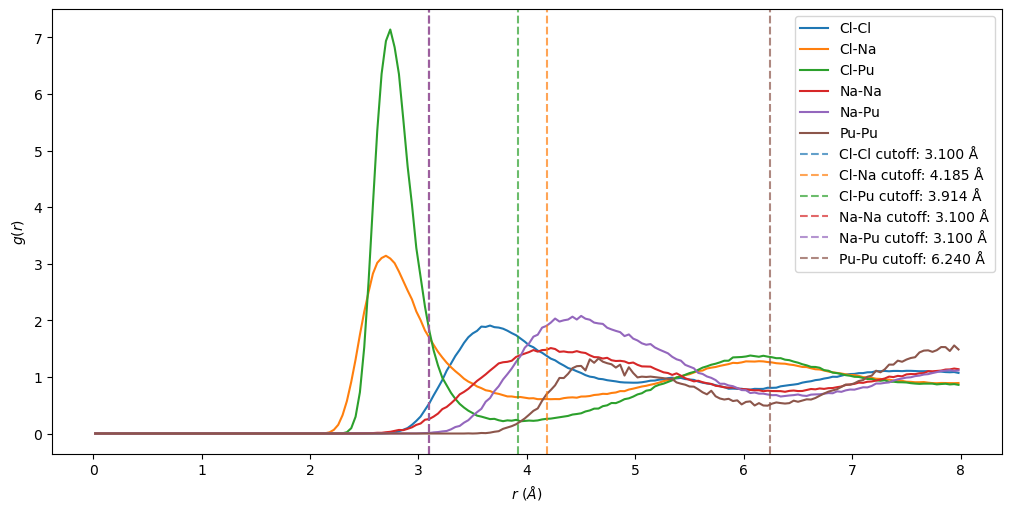

In [5]:
plot_rdfs(result["rdf"], cutoffs=cutoffs,figsize=(10, 5))

In [6]:
from scipy.signal import find_peaks, savgol_filter
from scipy.ndimage import gaussian_filter1d

In [7]:

def find_the_minimum(
    r: np.ndarray, 
    g: np.ndarray, 
    min_distance: float = 1.0, 
    max_distance: float = 8.0,
    prominence: float = 0.5,
    smooth_window: int = 11,
    poly_order: int = 2,
    smoothing_method: str = 'savgol',
    gaussian_sigma: float = 3.0
) :
    """Find first minimum using scipy's find_peaks with prominence, fallback to custom implementation.
    
    Primary method: Use scipy.signal.find_peaks on inverted g(r) with prominence filtering
    Fallback: Use the existing find_first_minimum_no_scipy implementation
    
    Args:
        r: Distance array
        g: RDF values
        min_distance: Minimum distance to consider
        max_distance: Maximum distance to consider  
        prominence: Minimum prominence for peaks (scipy method only)
        smooth_window: Window size for smoothing (must be odd for Savitzky-Golay)
        poly_order: Polynomial order for Savitzky-Golay filter
        smoothing_method: Method to use ('moving_avg', 'savgol', 'gaussian')
        gaussian_sigma: Standard deviation for Gaussian smoothing
        
    Returns:
        Distance of first minimum, or None if not found
    """


    
    # Restrict to window
    mask = (r >= min_distance) & (r <= max_distance)
    r_win = r[mask]
    g_win = g[mask]
    if r_win.size < 5:
        print('Window size is less than 5, falling back to custom method')
        return None
    
    try:
        # Apply smoothing based on selected method
        if smoothing_method == 'moving_avg':
            g_smooth = _moving_average(g_win, smooth_window)
        elif smoothing_method == 'savgol':
            g_smooth = savgol_smooth(g_win, smooth_window, poly_order)
        elif smoothing_method == 'gaussian':
            g_smooth = gaussian_smooth(g_win, gaussian_sigma, mode='nearest')
        else:
            raise ValueError(f"Unknown smoothing method: {smoothing_method}. Choose from: 'moving_avg', 'savgol', 'gaussian'")
        
        
        # Invert g(r) to find minima as peaks
        g_inverted = -g_smooth
        
        # Find peaks (minima in original) with prominence filtering
        peaks, properties = find_peaks(
            g_inverted, 
            prominence=prominence,
        )
        
        if len(peaks) > 0:
            # Find the first minimum after the first peak
            for peak in peaks:
                # Refine using quadratic interpolation
                return _quadratic_refine_minimum(r_win, g_smooth, peak)

                
        
        # If no suitable peaks found, fall back to custom method
        print('No suitable peaks found, falling back to custom method')
        # raise ValueError('No suitable peaks found, falling back to custom method')
        return None
        
    except Exception:
        import traceback
        traceback.print_exc()
        return None

In [8]:
def _moving_average(values: np.ndarray, window_size: int) -> np.ndarray:
    """Simple centered moving average with reflection at boundaries."""
    if window_size <= 1:
        return values
    pad = window_size // 2
    if pad == 0:
        return values
    extended = np.pad(values, pad_width=pad, mode='reflect')
    kernel = np.ones(window_size, dtype=float) / float(window_size)
    smoothed = np.convolve(extended, kernel, mode='valid')
    return smoothed

def savgol_smooth(data, window_size, poly_order):
    """
    Smooths data using a Savitzky-Golay filter.
    `window_size` must be odd.
    `poly_order` must be less than `window_size`.
    """
    return savgol_filter(data, window_size, poly_order)

def gaussian_smooth(data, sigma, mode='nearest'):
    """
    Smooths data with a 1D Gaussian filter.
    `sigma` is the standard deviation of the Gaussian kernel.
    `mode` controls how the array borders are handled (e.g., 'nearest', 'reflect').
    """
    return gaussian_filter1d(data, sigma, mode=mode)

def _quadratic_refine_minimum(r: np.ndarray, g: np.ndarray, i: int) -> float:
    """Refine the minimum location using quadratic interpolation around index i.

    Assumes near-uniform spacing in r, which holds for OVITO's RDF bins.
    Falls back to r[i] if refinement fails or i is at an edge.
    """
    if i <= 0 or i >= len(r) - 1:
        return float(r[i])
    g_im1, g_i, g_ip1 = float(g[i - 1]), float(g[i]), float(g[i + 1])
    denom = (g_im1 - 2.0 * g_i + g_ip1)
    if denom == 0.0:
        return float(r[i])
    # Estimate assuming uniform spacing
    dr = float(r[i] - r[i - 1])
    delta = 0.5 * dr * (g_im1 - g_ip1) / denom
    return float(r[i] + delta)

In [9]:
r=result["rdf"]["r"]
g=result["rdf"]["Cl-Pu"]


In [10]:
find_the_minimum(r, g, smoothing_method='savgol',prominence=0.1)

3.914469342872374

In [11]:
find_the_minimum(r, g, smoothing_method='gaussian')

3.9354099581612783

In [12]:
find_the_minimum(r, g, smoothing_method='moving_avg')

3.9318801704664232

In [13]:
find_the_minimum(result["rdf"]["r"], result["rdf"]["Pu-Pu"],prominence=0.01)

6.239619635498403

In [14]:
from matplotlib import pyplot as plt
plt.plot(result["rdf"]["r"],result["rdf"]["Pu-Pu"])

In [15]:
from matplotlib import pyplot as plt

In [19]:
fiig = plt.figure()

In [30]:
dff=dict()
for key in result["rdf"].keys():
    fa=find_the_minimum(result["rdf"]["r"], result["rdf"][key],prominence=0.1)
    print("key",key,fa)
    if fa== None:
        fa=0
    dff[key]=fa

key Na-Na 6.409229329704387
key Cl-Na 4.185418689002375
key Na-Pu 6.406772566137578
key Cl-Cl 6.019275291968649
key Cl-Pu 3.914469342872374
key Pu-Pu 6.239619635498403
No suitable peaks found, falling back to custom method
key r None


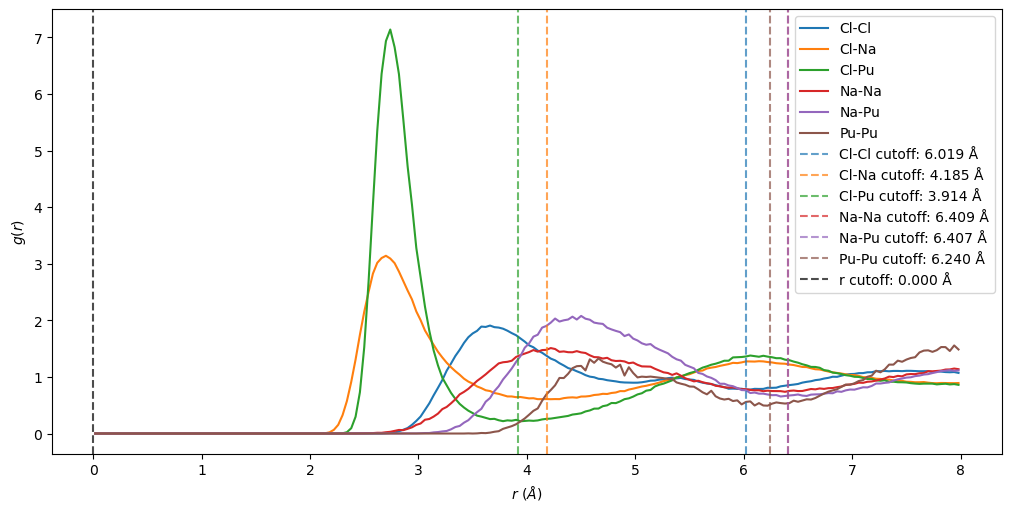

In [31]:
plot_rdfs(rdf_data=result["rdf"],cutoffs=dff,figsize=(10,5))